In [1]:
# Load dataset and view basic structure

import pandas as pd
import numpy as np

df=pd.read_csv("best-buy-products.csv")
df = df[["sku","name", "customerReviewAverage", "customerReviewCount", "customerTopRated", "manufacturer", "class", "condition", "modelNumber",  "salePrice"]]

# Display the first 5 rows for a quick preview
df.head()

,sku,name,customerReviewAverage,customerReviewCount,customerTopRated,manufacturer,class,condition,modelNumber,salePrice
0,6636904,"Lenovo - T14 G2 14"" Refurbished Laptop - Intel...",3.0,1.0,False,Lenovo,SO LAPTOPS,Refurbished,T14 G2,677.99
1,6636905,"HP - EliteBook 840 G7 14"" Refurbished Laptop -...",NaN,NaN,NaN,HP,SO LAPTOPS,Refurbished,840 G7,574.99
2,6636906,"HP - EliteBook 850 G7 15.6"" Refurbished Laptop...",NaN,NaN,NaN,HP,SO LAPTOPS,Refurbished,850 G7,721.18
3,6636931,"HP - OmniBook X - Copilot+ PC - 17.3"" Full HD ...",4.8,51.0,True,HP,BLUE LABEL,New,C33WSUA#ABA,1599.99
4,6637409,"HP - 15.6"" Laptop - Intel Core i3 - 8GB Memory...",4.7,196.0,True,HP,BURST,New,C0CM1UA#ABA,219.99


In [3]:
#remove rows that are empty
df = df.dropna()

In [4]:
# Check structure
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 846 entries, 0 to 1223
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sku                    846 non-null    int64  
 1   name                   846 non-null    object 
 2   customerReviewAverage  846 non-null    float64
 3   customerReviewCount    846 non-null    float64
 4   customerTopRated       846 non-null    object 
 5   manufacturer           846 non-null    object 
 6   class                  846 non-null    object 
 7   condition              846 non-null    object 
 8   modelNumber            846 non-null    object 
 9   salePrice              846 non-null    float64
dtypes: float64(3), int64(1), object(6)
memory usage: 72.7+ KB


In [5]:
df.isna().sum()

sku                      0
name                     0
customerReviewAverage    0
customerReviewCount      0
customerTopRated         0
manufacturer             0
class                    0
condition                0
modelNumber              0
salePrice                0
dtype: int64

In [19]:
# Average Rating by Manufacturer

df.groupby("manufacturer")["customerReviewAverage"].mean().sort_values(ascending=False)


manufacturer
Google       5.000000
LG           4.800000
Lenovo       4.576190
HP           4.482443
ASUS         4.430137
Samsung      4.325000
Dell         4.256000
Acer         4.218750
Apple        4.200243
HP OMEN      4.000000
MSI          3.800000
Microsoft    3.650000
GIGABYTE     3.133333
Thomson      3.000000
Name: customerReviewAverage, dtype: float64

In [33]:
# Statistical Checking — Pearson Correlation

df[numeric_cols].corr(method="pearson")


,salePrice,customerReviewAverage,customerReviewCount
salePrice,1.000000,0.014183,-0.055356
customerReviewAverage,0.014183,1.000000,0.153745
customerReviewCount,-0.055356,0.153745,1.000000


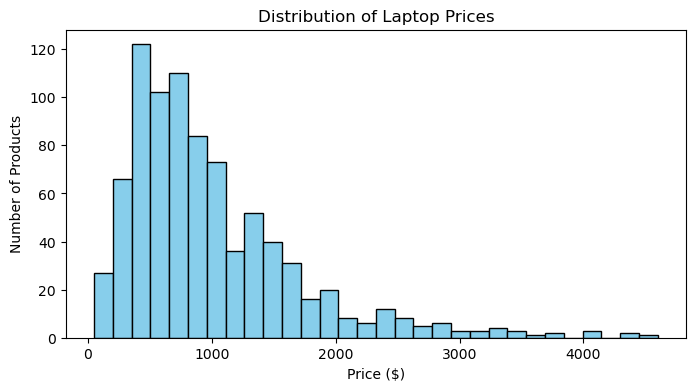

In [35]:
# Price Distribution

plt.figure(figsize=(8,4))
plt.hist(df['salePrice'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Price ($)")
plt.ylabel("Number of Products")
plt.title("Distribution of Laptop Prices")
plt.show()


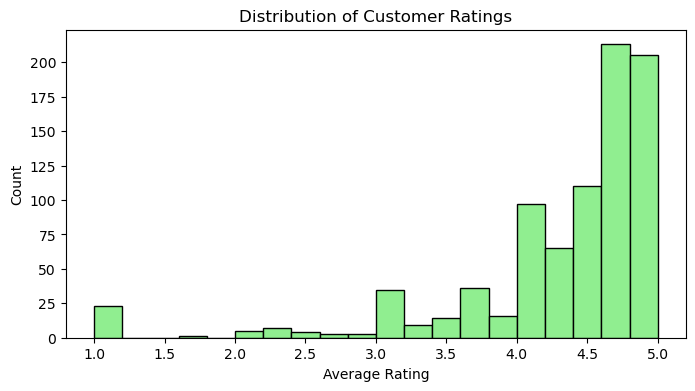

In [36]:
# Rating Distribution

plt.figure(figsize=(8,4))
plt.hist(df['customerReviewAverage'], bins=20, color='lightgreen', edgecolor='black')
plt.xlabel("Average Rating")
plt.ylabel("Count")
plt.title("Distribution of Customer Ratings")
plt.show()


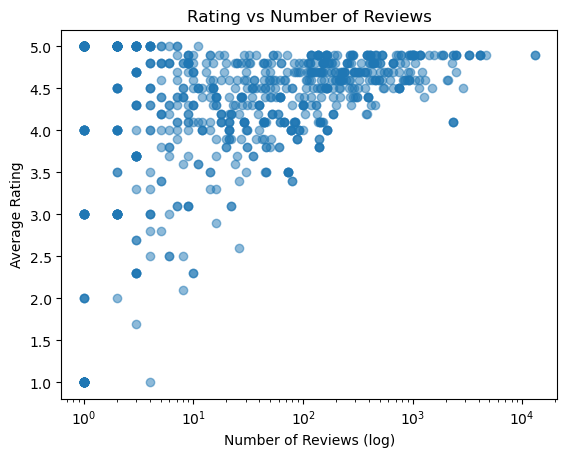

In [51]:
# Average Rating Distribution

#plt.figure(figsize=(6,6))
plt.scatter(df['customerReviewCount'], df['customerReviewAverage'], alpha=0.5)
plt.xscale("log")
plt.xlabel("Number of Reviews (log)")
plt.ylabel("Average Rating")
plt.title("Rating vs Number of Reviews")
plt.show()



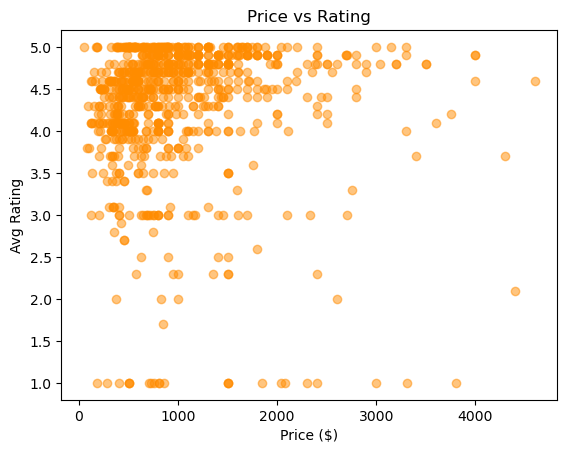

In [55]:
# Price vs Rating (Scatter)

#plt.figure(figsize=(6,6))
plt.scatter(df['salePrice'], df['customerReviewAverage'], alpha=0.5, color='darkorange')
plt.xlabel("Price ($)")
plt.ylabel("Avg Rating")
plt.title("Price vs Rating")
plt.show()


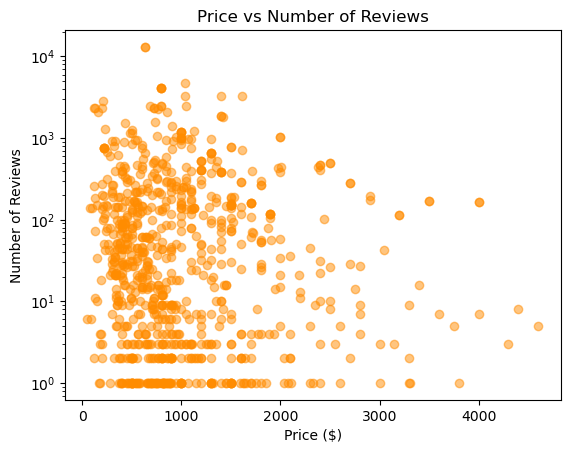

In [54]:
# Price vs Review Count (Scatter)

#plt.figure(figsize=(6,6))
plt.scatter(df['salePrice'], df['customerReviewCount'], alpha=0.5, color='darkorange')
plt.yscale("log")
plt.xlabel("Price ($)")
plt.ylabel("Number of Reviews")
plt.title("Price vs Number of Reviews")
plt.show()


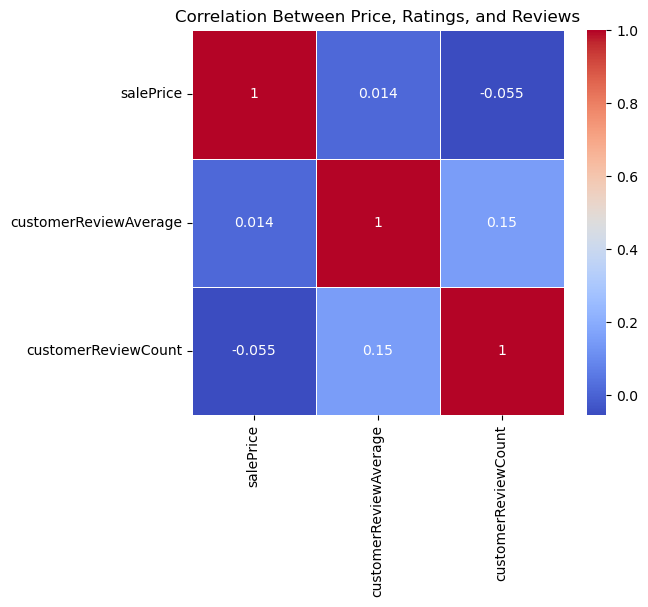

In [ ]:
# Correlation Heatmap

numeric_cols = ["salePrice", "customerReviewAverage", "customerReviewCount"]

plt.figure(figsize=(6,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between Price, Ratings, and Reviews")
plt.show()


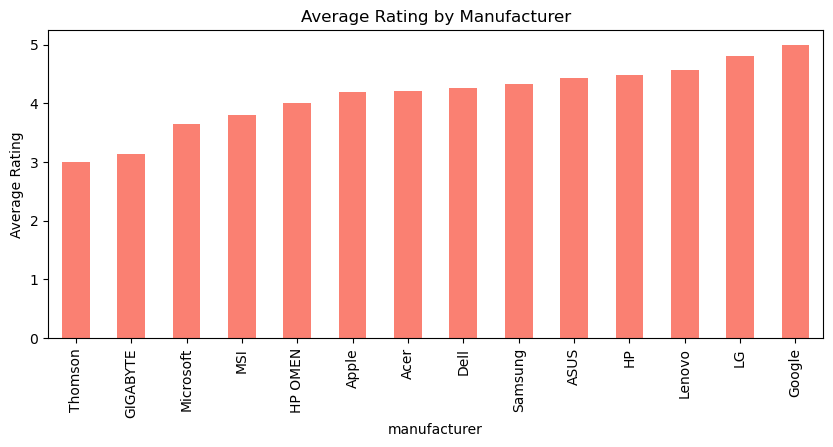

In [ ]:
# # Average Rating by Manufacturer (Bar Chart)

plt.figure(figsize=(10,4))
(df.groupby("manufacturer")["customerReviewAverage"]
   .mean()
   .sort_values()
   .plot(kind='bar', color='salmon'))
plt.ylabel("Average Rating")
plt.title("Average Rating by Manufacturer")
plt.show()




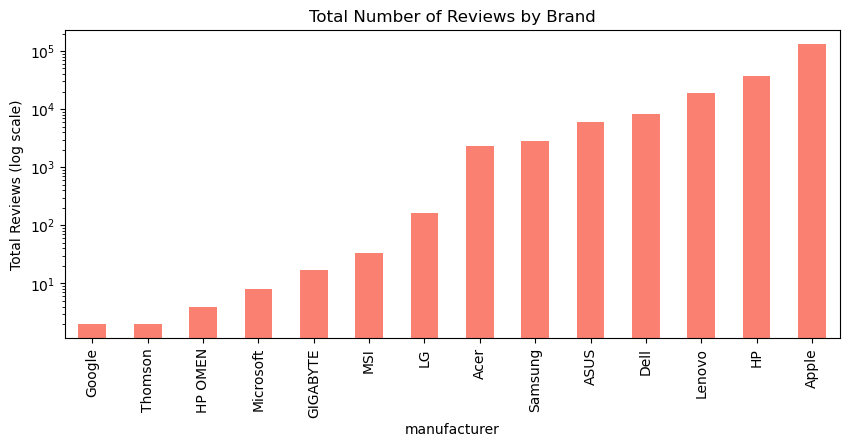

In [61]:
# Reviews by Manufacturer (Bar Chart)

plt.figure(figsize=(10,4))
(df.groupby("manufacturer")["customerReviewCount"]
   .sum()
   .sort_values()
   .plot(kind='bar', color='salmon'))
plt.ylabel("Total Reviews (log scale)")
plt.yscale("log")
plt.title("Total Number of Reviews by Brand")
plt.show()

